##### Imports and Settings

In [84]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [85]:
# Imports
from ast import literal_eval
from copy import deepcopy
from enum import Enum
from pprint import pprint

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as f
from huggingface_hub import parse_safetensors_file_metadata
from IPython.display import HTML, Video
from matplotlib.animation import FFMpegWriter, FuncAnimation
from matplotlib.pyplot import figure
from pydmd import BOPDMD, DMD, HAVOK, HODMD, FbDMD, HankelDMD, OptDMD
from pydmd.plotter import plot_eigs, plot_summary
from pydmd.preprocessing import hankel_preprocessing
from safetensors.torch import load_model
from torch.nn import MSELoss
from torch.optim import SGD
from torch.utils.data import DataLoader
from torchinfo import summary

from algo.embedding import dehankel, hankel, make_hankel_matrix
from algo.lda import lda
from algo.mean_classifier import mean_classifier
from data import (
    GaussianDataset,
    LinearGaussianDataset,
    RectangularDataset,
    SpiralDataset,
    YinYangDataset,
)
from models.perceptron import MLP, HiddenLayerModel, SingleNeuronModel, init_weights
from saved_weights import parser
from visualization.boundary import extract_layer_weights, plot_decision_boundary_movie

%matplotlib inline

In [86]:
%load_ext matrepr
import matrepr
from matrepr import mdisplay, mprint

matrepr.params.title = True
matrepr.params.indices = False
matrepr.params.precision = 5

The matrepr extension is already loaded. To reload it, use:
  %reload_ext matrepr


In [87]:
# Custom formatter function
def my_formatter(x):
    if abs(x) < 1e-0 or abs(x) >= 1e0:  # Threshold for scientific notation
        return f"{x:.2e}"  # Format as scientific with 2 decimal places
    else:
        return f"{x:.2f}"  # Format as decimal with 2 decimal places


# Set print options with custom formatter
torch.set_printoptions(linewidth=500, precision=4, sci_mode=True, profile="full")
np.set_printoptions(linewidth=500, formatter={"float_kind": my_formatter})

##### Model and Dataset Load

In [88]:
file_path = "../saved_weights/model.safetensors"
metadata = parser.safetensors_metadata_parser(file_path=file_path)

model = MLP(config=literal_eval(metadata["config"]))
load_model(model, file_path, device="cuda:0")

model

MLP(
  (features): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=False)
    (1): Tanh()
    (2): Linear(in_features=5, out_features=5, bias=False)
    (3): Tanh()
    (4): Linear(in_features=5, out_features=1, bias=False)
    (5): Tanh()
  )
)

In [89]:
HIDDEN = 5

In [90]:
PROBLEM = metadata["dataset"]
NUM_SAMPLES = 500
NUM_GAUSS_FEATURES = 0

# Build dataset
if PROBLEM == "yinyang":
    dataset = YinYangDataset(size=NUM_SAMPLES)
else:
    raise NotImplementedError()

In [91]:
sample_size = 2
num_samples = dataset.features.shape[0]


all_indices = np.arange(num_samples)
train_indices = np.random.choice(
    dataset.features.shape[0], size=sample_size, replace=False
)
test_indices = np.random.choice(
    np.setdiff1d(all_indices, train_indices), size=sample_size, replace=False
)

In [92]:
mprint(train_indices)

<length=2, 2 'int64' elements, array>
[282, 345]


In [93]:
mprint(test_indices)

<length=2, 2 'int64' elements, array>
[96, 218]


In [94]:
def getActivation(name, activation_dict):
    # the hook signature
    def hook(model, input, output):
        activation_dict[name] = output.detach()

    return hook

In [95]:
# a dict to store the activations
activation_dict = {}

h1_name = "pre_layer"
h2_name = "post_layer"

h1 = model.features[1].register_forward_hook(getActivation(h1_name, activation_dict))
h2 = model.features[3].register_forward_hook(getActivation(h2_name, activation_dict))

out = model(dataset.features)

h1.remove()
h2.remove()

pre_act = activation_dict[h1_name][train_indices]
post_act = activation_dict[h2_name][train_indices]

In [96]:
mprint(pre_act)

<2×5, 'torch.float32' elements, torch.strided>
┌                                                ┐
│    -1     0.96397  -0.38222  -0.8826   0.86919 │
│ -0.99999  0.94647  -0.40498  -0.84182  0.82563 │
└                                                ┘


In [97]:
mprint(post_act)

<2×5, 'torch.float32' elements, torch.strided>
┌                                                ┐
│ -0.99689  0.32406  -0.74607  0.79599  -0.9967  │
│ -0.99424  0.20543  -0.86681  0.79952  -0.99812 │
└                                                ┘


Layer Looping 

In [98]:
train_looping_inputs = pre_act[:1, :]
mprint(train_looping_inputs)

<1×5, 'torch.float32' elements, torch.strided>
┌                                         ┐
│ -1  0.96397  -0.38222  -0.8826  0.86919 │
└                                         ┘


In [99]:
test_looping_inputs = pre_act[1:2, :]
mprint(test_looping_inputs)

<1×5, 'torch.float32' elements, torch.strided>
┌                                                ┐
│ -0.99999  0.94647  -0.40498  -0.84182  0.82563 │
└                                                ┘


In [100]:
num_iterations = 10  # Specify the number of iterations

In [101]:
def iterate_layer(inputs, layers, num_iterations):
    # Initialize the input tensor
    input_tensor = inputs.clone()

    # List to store the outputs at each iteration
    outputs = []

    # Loop for the specified number of iterations
    with torch.no_grad():
        for _ in range(num_iterations):
            # Pass the input through the layers
            for layer in layers:
                input_tensor = layer(input_tensor)

            # Store the output
            outputs.append(input_tensor.detach().clone())

    return outputs


train_states = torch.cat(
    iterate_layer(
        inputs=train_looping_inputs,
        # layers=[model.features[2]],
        layers=[model.features[2], model.features[3]],
        num_iterations=num_iterations,
    )
)

train_states = torch.cat((train_looping_inputs, train_states))

In [102]:
train_states.shape

torch.Size([11, 5])

Verify

In [103]:
mprint(train_states.T[:, :HIDDEN])

<5×5, 'torch.float32' elements, torch.strided>
┌                                                  ┐
│    -1     -0.99689     1      0.99981   0.99938  │
│ 0.96397   0.32406   -0.99495  -0.99993  -0.98622 │
│ -0.38222  -0.74607     -1     -0.2306   0.19555  │
│ -0.8826   0.79599   0.56543    0.722     -0.24   │
│ 0.86919   -0.9967      -1     -0.99852  0.07859  │
└                                                  ┘


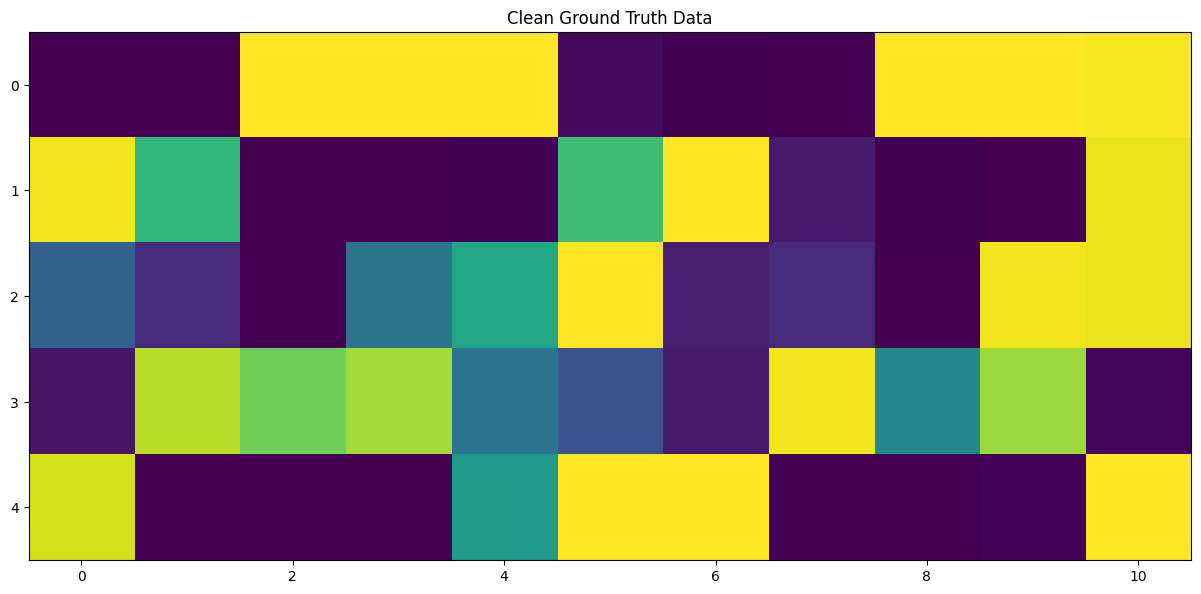

In [104]:
fig = plt.figure(figsize=(15, 15))
plt.title("Clean Ground Truth Data")
plt.imshow(train_states.T)
plt.show()

DMD

In [105]:
d = 4

/usr/local/lib/python3.10/dist-packages/pydmd/bopdmd.py:751: UserWarning: Initial trial of Optimized DMD failed to converge. Consider re-adjusting your variable projection parameters with the varpro_opts_dict and consider setting verbose=True.
  warnings.warn(msg)


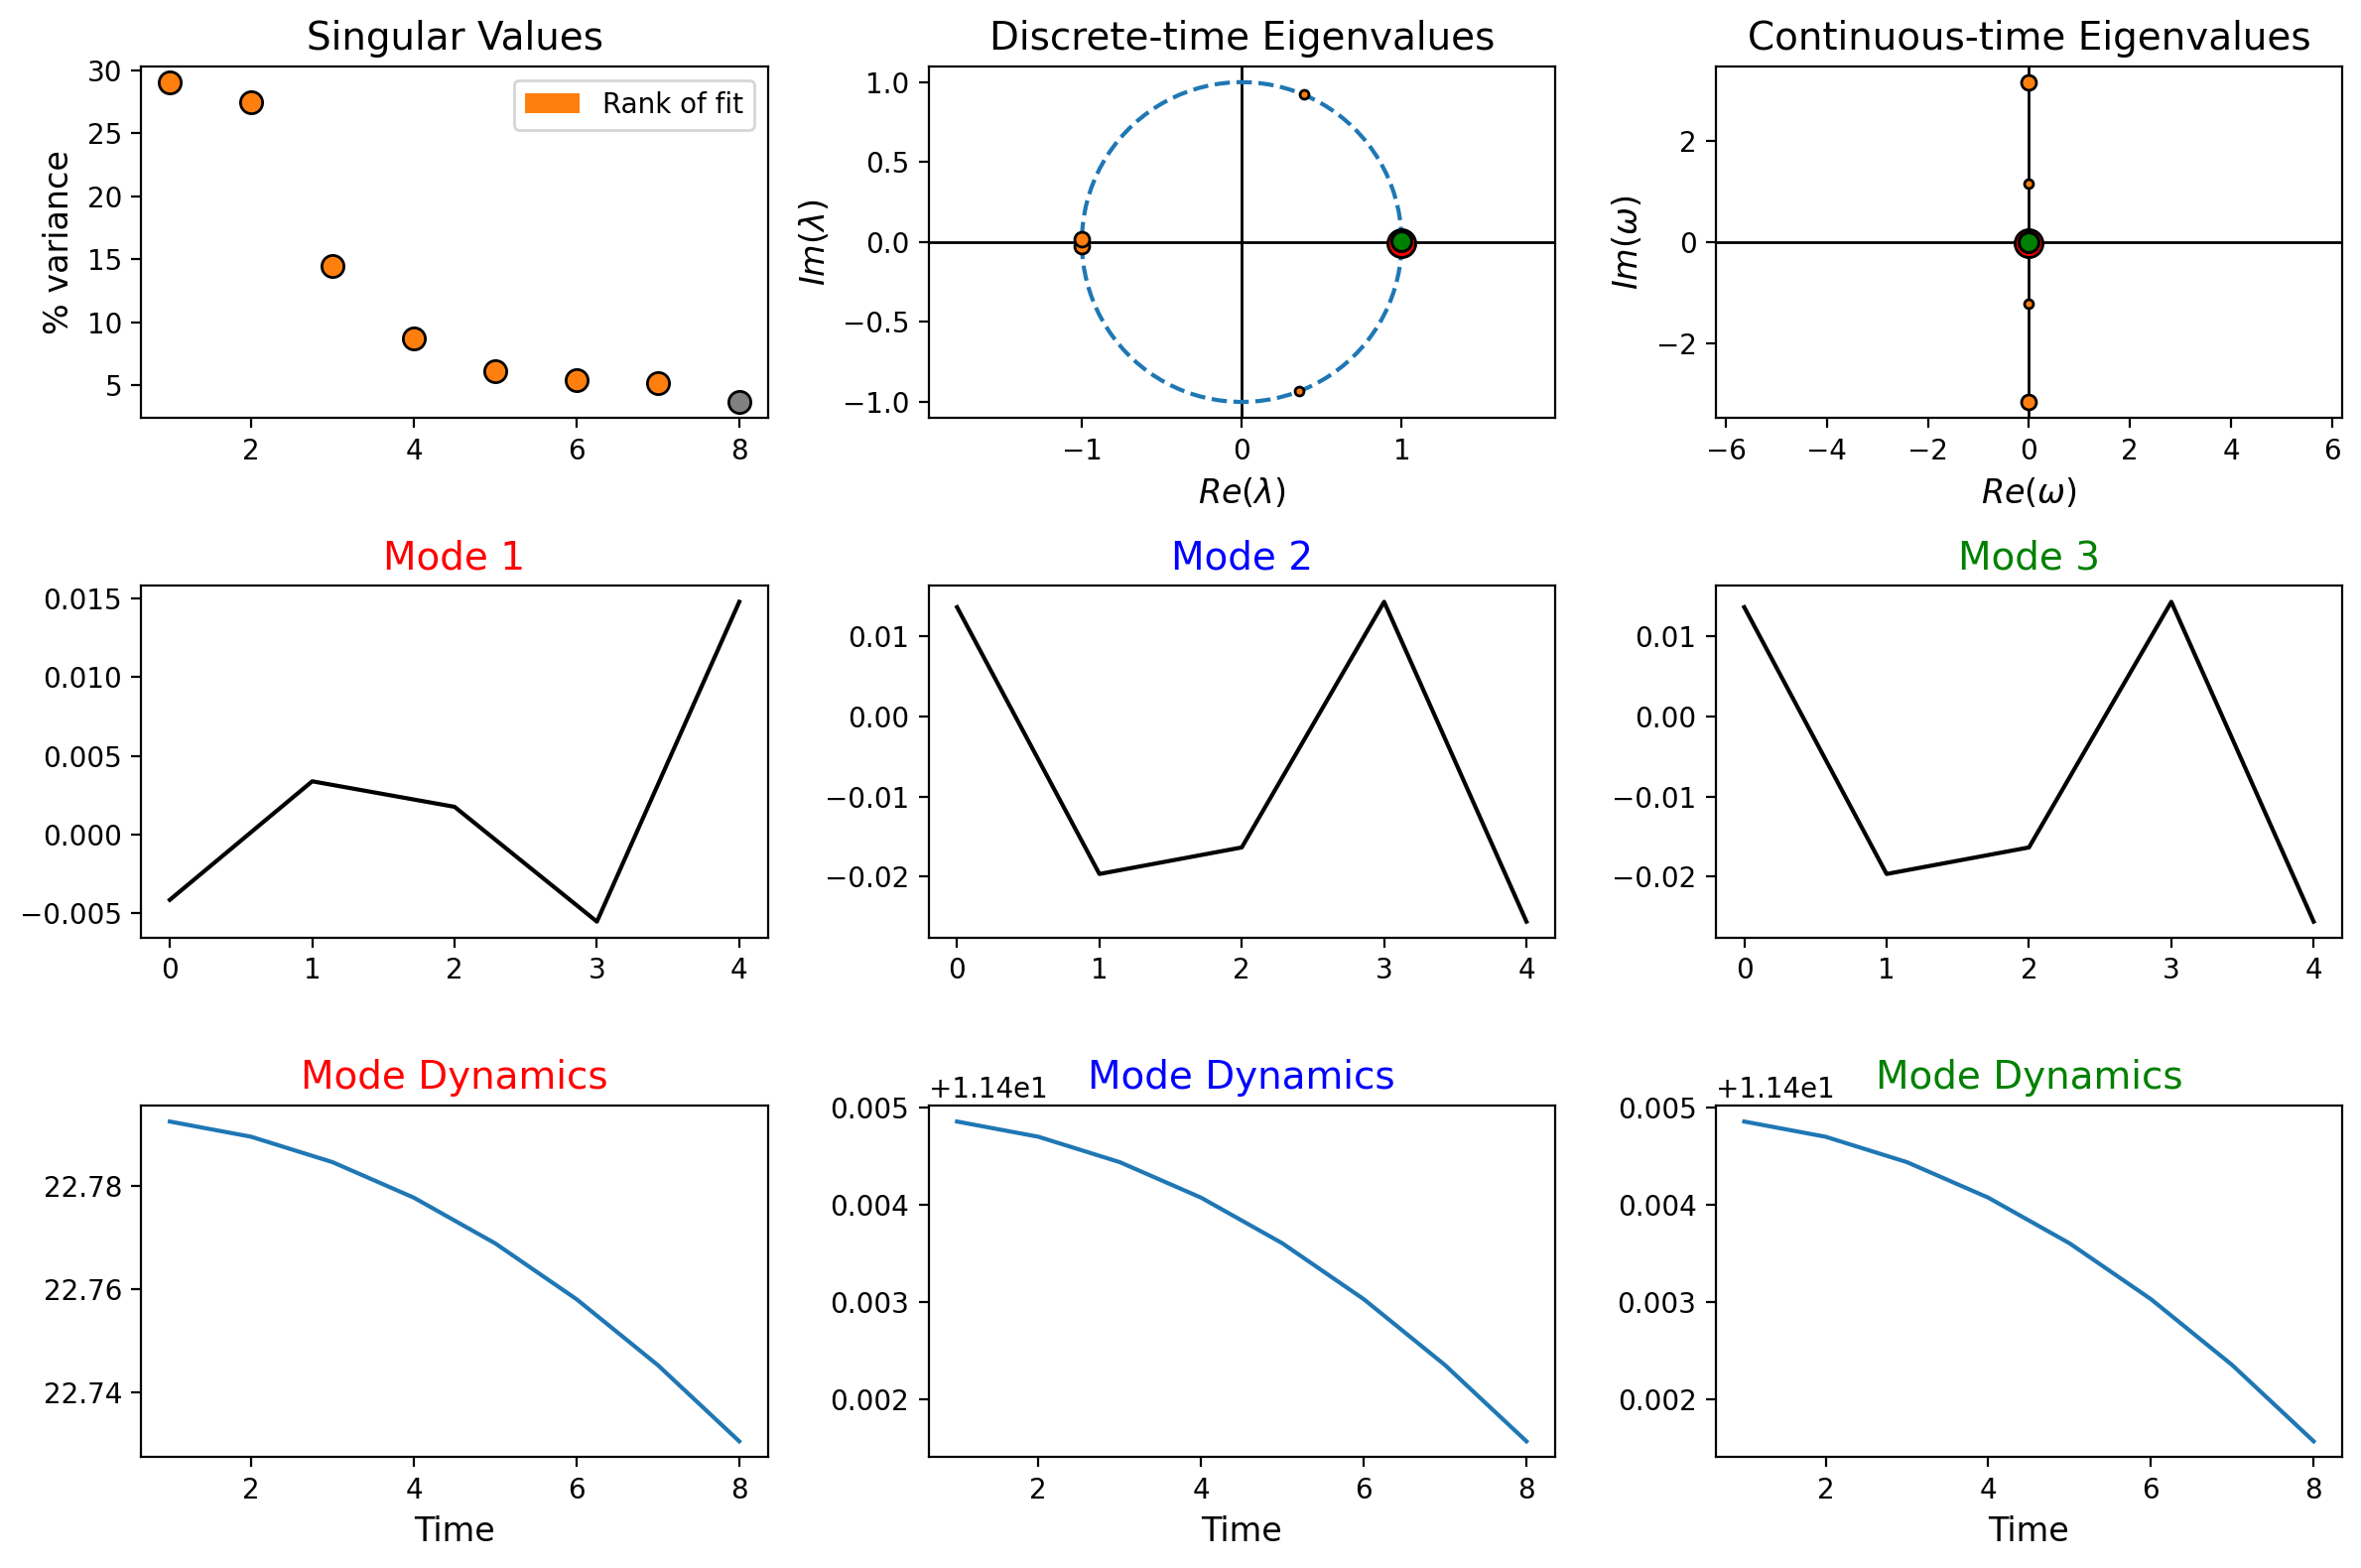

In [106]:
dmd = BOPDMD(
    svd_rank=15,
    num_trials=0,
    eig_constraints={"imag"},
    compute_A=True,
)
delay_dmd = hankel_preprocessing(dmd, d=d)
t = np.linspace(1, train_states.shape[0], train_states.shape[0])
delay_t = t[: -d + 1]
delay_dmd.fit(train_states.numpy().T, t=delay_t)
plot_summary(delay_dmd, d=d)

In [107]:
# dmd = DMD(svd_rank=3)
# delay_dmd = hankel_preprocessing(dmd, d=d)
# delay_dmd.fit(train_states.numpy().T)
# plot_summary(delay_dmd, d=d)

In [108]:
# dmd = DMD(svd_rank=3, exact=False, opt=False)
# # delay_dmd = dmd
# delay_dmd = hankel_preprocessing(dmd, d=d)
# delay_dmd.fit(train_states.numpy().T)
# plot_summary(delay_dmd, d=d)

In [109]:
delay_dmd.reconstructed_data.shape

(5, 11)

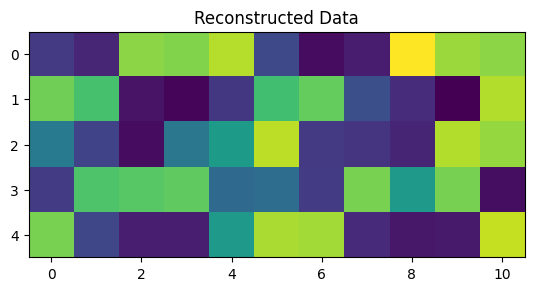

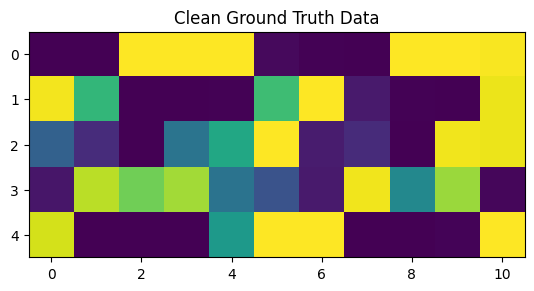

In [110]:
plt.title("Reconstructed Data")
plt.imshow(delay_dmd.reconstructed_data.real)
plt.show()
plt.title("Clean Ground Truth Data")
plt.imshow(train_states.T)
plt.show()

In [111]:
mprint(hankel(train_states.T, delays=d))

<20×8, 'torch.float32' elements, torch.strided>
┌                                                                  ┐
│    -1     -0.99689  0.99981   ...  -0.95188   -0.98686  -0.99511 │
│ 0.96397   0.32406   -0.99993  ...   0.37987   0.99996   -0.85342 │
│ -0.38222  -0.74607  -0.2306   ...      1      -0.84574  -0.75753 │
│ -0.8826   0.79599    0.722    ...  -0.48939   -0.85426  0.95365  │
│ 0.86919   -0.9967   -0.99852  ...   0.99999   0.99812   -0.99995 │
│    :         :         :      ...      :         :         :     │
│ 0.99981   0.99938   -0.98686  ...      1      0.99286   0.98254  │
│ -0.99993  -0.98622  0.99996   ...  -0.98546   -0.99985   0.9415  │
│ -0.2306   0.19555   -0.84574  ...     -1      0.95357   0.93962  │
│  0.722     -0.24    -0.85426  ...  -0.063991  0.69995   -0.96667 │
│ -0.99852  0.07859   0.99812   ...     -1      -0.98426  0.99999  │
└                                                                  ┘


In [112]:
mprint(dmd.A)

<20×20, 400 'complex128' elements, array>
┌                                                                   ┐
│  2.8543--0.29125i     -2.5694+0.28484i   ...  -0.29593+0.007243i  │
│   1.9388+0.18761i     -1.5001--0.1447i   ...  -0.32748--0.047328i │
│   -1.071+0.30151i     1.0439--0.26242i   ...  0.21826--0.034862i  │
│ -0.042461--0.14821i  -0.10488+0.12577i   ...  -0.021383+0.022977i │
│  -0.51867+0.26209i   0.64547--0.22841i   ...  0.091674--0.033277i │
│          :                   :           ...           :          │
│  -2.8678+0.29146i     2.581--0.28494i    ...  0.29865--0.0071167i │
│  -5.2232--0.25985i    4.2696+0.16943i    ...   0.74319+0.095077i  │
│ -0.96119--0.31977i    0.68189+0.25605i   ...  0.015611+0.062798i  │
│  3.0689+0.098248i    -2.5034--0.053446i  ...  -0.40319--0.049082i │
│  -3.0151--0.31226i     2.3479+0.2357i    ...   0.39862+0.079972i  │
└                                                                   ┘


In [113]:
product = torch.from_numpy(dmd.A) @ hankel(train_states.T, delays=d).to(torch.cdouble)
mprint(product)

<20×8, 'torch.complex128' elements, torch.strided>
┌                                                              ┐
│  9.247--1.0117i    -8.0697+0.73602i   ...  -8.1296+0.61357i  │
│  6.1306+0.59654i   -5.1365--0.58686i  ...  -7.4551--0.68996i │
│ -4.8844+0.98103i   4.2569--0.83032i   ...   3.892--0.9017i   │
│ 0.79106--0.47694i  -0.88533+0.43006i  ...  0.17313+0.44375i  │
│ -2.9692+0.85357i   2.8538--0.73521i   ...  1.5863--0.75112i  │
│         :                  :          ...          :         │
│  -9.2974+1.0112i    8.1116--0.7352i   ...   8.178--0.61366i  │
│ -16.36--0.76911i    13.851+0.88325i   ...   17.882+1.2118i   │
│  -1.424--1.0225i    1.3089+0.96186i   ...   2.6788+1.1555i   │
│  9.3195+0.2778i    -7.8024--0.3795i   ...  -10.103--0.53871i │
│ -8.5094--0.97261i   7.0005+0.98392i   ...   10.136+1.2062i   │
└                                                              ┘


Sanity Check

In [114]:
def forecast_from_state(dmd, x0, d, t):
    # Hankelize the initial state
    x0_hankel = hankel(x0, delays=d)

    modes = torch.from_numpy(dmd.modes)
    eigs = torch.from_numpy(dmd.eigs)

    # Project the Hankelized initial state onto the DMD modes
    b = torch.linalg.lstsq(modes, x0_hankel.type(torch.cdouble), rcond=None).solution

    # Forecast each individual state and store in a list
    x_hankel_list = []
    for i in range(len(t)):
        # Ensure correct broadcasting by adding a new axis to 'b'
        x_hankel_i = modes @ (b * torch.exp(eigs * t[i]).unsqueeze(1))
        x_hankel_list.append(x_hankel_i)

    # Stack the forecasted states horizontally to create a Hankelized matrix
    x_hankel = torch.hstack(x_hankel_list)

    # De-Hankelize the prediction to get back the original variables
    x = dehankel(x_hankel, HIDDEN)

    return x

In [115]:
# Hankelize the matrix with delay
# Grab 0 column to show input into the DMD matrix
mprint(hankel(train_states.T, delays=d)[:HIDDEN, :1])

<5×1, 'torch.float32' elements, torch.strided>
┌          ┐
│    -1    │
│ 0.96397  │
│ -0.38222 │
│ -0.8826  │
│ 0.86919  │
└          ┘


In [116]:
# Grab the first three states
mprint(train_states.T)

<5×11, 'torch.float32' elements, torch.strided>
┌                                                                            ┐
│    -1     -0.99689     1      -0.95188  ...      1      0.99286   0.98254  │
│ 0.96397   0.32406   -0.99495  0.37987   ...  -0.98546   -0.99985   0.9415  │
│ -0.38222  -0.74607     -1        1      ...     -1      0.95357   0.93962  │
│ -0.8826   0.79599   0.56543   -0.48939  ...  -0.063991  0.69995   -0.96667 │
│ 0.86919   -0.9967      -1     0.99999   ...     -1      -0.98426  0.99999  │
└                                                                            ┘


In [117]:
###### ORIGINAL #####
# Predict next set of vectors
# if d=2, should be columns 1 and 2
# Reshape for easy view
pred = delay_dmd.forecast(t=1).real
mprint(torch.from_numpy(pred.reshape((HIDDEN, -1), order="F")))

<5×4, 'torch.float64' elements, torch.strided>
┌                                        ┐
│ -0.79282  -0.9417   0.84384    0.8102  │
│ 0.74041   0.55193    -1.083    -1.176  │
│ -0.18662  -0.7058   -1.1307   -0.22637 │
│ -0.7746   0.59737   0.63405   0.67123  │
│  0.7809   -0.68431  -0.99736   -1.001  │
└                                        ┘


In [118]:
forecast = forecast_from_state(delay_dmd, train_states.T, d, [1])
mprint(forecast)

<5×11, 'torch.float32' elements, torch.strided>
┌                                                                      ┐
│ -0.94538  1.1352   1.0591   -1.0369   ...  1.0058   0.83802  -1.621  │
│ 0.48702   -1.059   -1.1787  0.16299   ...  -1.7136  1.1533   0.49584 │
│ -0.75103  -1.1287  0.10637  -1.0194   ...  0.7817   0.97298  0.71235 │
│  0.6998   0.68323  0.76218  -0.50481  ...  1.0171   -1.2231  0.14581 │
│ -0.85984  -1.1961  -1.0121  0.49268   ...  -1.4444   1.224   0.34022 │
└                                                                      ┘


/app/algo/embedding.py:78: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at /opt/pytorch/pytorch/aten/src/ATen/native/Copy.cpp:299.)
  X[i, j * lag : j * lag + Hm] = H[j * n + i]


In [119]:
# Calculate the squared error
squared_error = (train_states.T[:, 1] - forecast[:, 0]) ** 2
torch.mean(squared_error)

tensor(1.1443e-02)

Testing

In [120]:
test_states = torch.cat(
    iterate_layer(
        inputs=test_looping_inputs,
        # layers=[model.features[2]],
        layers=[model.features[2], model.features[3]],
        num_iterations=num_iterations,
    )
)

test_states = torch.cat((test_looping_inputs, test_states))

In [121]:
# Hankelize the matrix with delay
# Grab 0 column to show input into the DMD matrix
mprint(hankel(test_states.T, delays=d)[:HIDDEN, :1])

<5×1, 'torch.float32' elements, torch.strided>
┌          ┐
│ -0.99999 │
│ 0.94647  │
│ -0.40498 │
│ -0.84182 │
│ 0.82563  │
└          ┘


In [122]:
# Grab the first three states
mprint(test_states.T)

<5×11, 'torch.float32' elements, torch.strided>
┌                                                                           ┐
│ -0.99999  -0.99424     1      0.89225   ...  -0.99989  -0.9995   -0.94815 │
│ 0.94647   0.20543   -0.99757  -0.87381  ...  0.99984   0.99837    0.5726  │
│ -0.40498  -0.86681     -1      0.9974   ...  0.55257   -0.1755   -0.99155 │
│ -0.84182  0.79952   0.63548   -0.41811  ...  -0.6089   -0.23093  0.69195  │
│ 0.82563   -0.99812     -1     0.98812   ...  0.99658   0.87834   -0.99742 │
└                                                                           ┘


In [123]:
forecast = forecast_from_state(delay_dmd, test_states.T, d, [1])
mprint(forecast)

<5×11, 'torch.float32' elements, torch.strided>
┌                                                                       ┐
│ -0.54218   1.2777    1.8056   -1.4212  ...  0.44978  1.2073   1.5378  │
│ -0.30527  -0.89417  -1.2673   3.5745   ...  -2.8142  -4.8437  -3.3131 │
│ -0.99423  -0.89703  0.93089   1.4611   ...  -1.6945  -2.3619  -1.3336 │
│ 0.71324   0.69797   0.60561   -1.8209  ...  1.8377   2.5595   1.6483  │
│ -0.90484  -1.6242   -0.91097   2.811   ...  -2.8694  -3.797   -2.6008 │
└                                                                       ┘


In [124]:
# # Predict next set of vectors
# # if d=2, should be columns 1 and 2
# # Reshape for easy view
# pred = delay_dmd.predict(hankel(test_states.T, delays=d)[:, :1]).real
# torch.from_numpy(pred.reshape((10, -1), order="F"))

In [125]:
# Calculate the squared error
squared_error = (test_states.T[:, 1] - forecast[:, 0]) ** 2
torch.mean(squared_error)

tensor(9.9513e-02)

In [126]:
# plt.title("Predicted Data")
# plt.imshow(torch.from_numpy(pred.reshape((10, -1), order="F")))
# plt.show()
# plt.title("Clean Ground Truth Data")
# plt.imshow(test_states.T[:, 1 : d + 1])
# plt.show()